## ***1. Problem Statement***

***The goal of this project is to predict a student's probability of admission*** 
***based on academic and profile features such as GRE score, TOEFL score, CGPA,***
***SOP rating, LOR rating, and University Rating.***

***This is a regression problem because the target variable (Chance of Admit)*** 
***is continuous.***

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
data = pd.read_csv('Admission_Predict.csv')

In [31]:
data.shape

(400, 9)

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [33]:
data.isnull().any()

Serial No.           False
GRE Score            False
TOEFL Score          False
University Rating    False
SOP                  False
LOR                  False
CGPA                 False
Research             False
Chance of Admit      False
dtype: bool

In [34]:
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [35]:
data.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [36]:
data.duplicated().any() #here we are checking for the duplicates in the dataframe 

np.False_

## ***2. Data Exploration***

***- The dataset contains 400 rows and 9 columns.***

***- There are no missing values.***

***- There are no duplicate values.***

***- The target variable is 'Chance of Admit'.***

***- Most features are numerical.***

In [37]:
data.corr() 
# here we are checking correlation of dependent variable with the independent variable 
# and to see which feature is correlated in the bes way

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,1.000000,-0.097526,-0.147932,-0.169948,-0.166932,-0.088221,-0.045608,-0.063138,0.042336
GRE Score,-0.097526,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.802610
TOEFL Score,-0.147932,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.791594
University Rating,-0.169948,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.711250
SOP,-0.166932,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.675732
LOR,-0.088221,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.669889
CGPA,-0.045608,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.873289
Research,-0.063138,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.553202
Chance of Admit,0.042336,0.802610,0.791594,0.711250,0.675732,0.669889,0.873289,0.553202,1.000000


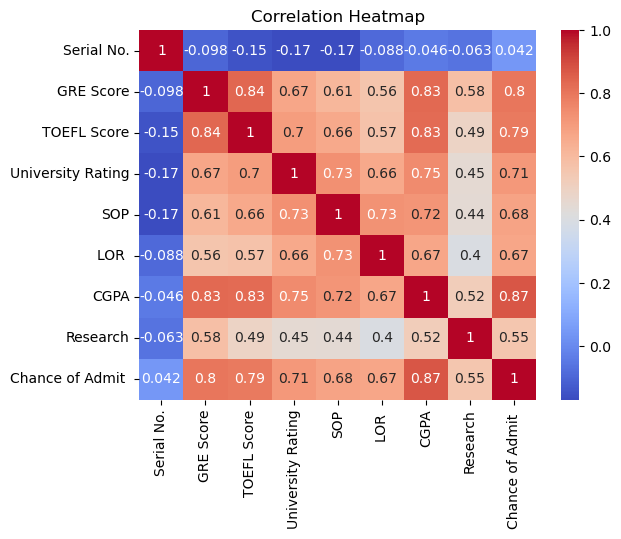

In [38]:
# here we are visualizing the correlation
plt.Figure(figsize=(15,10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
# here we are checking the correlation specifically with our dependent variabl
data.corr()['Chance of Admit ']

Serial No.           0.042336
GRE Score            0.802610
TOEFL Score          0.791594
University Rating    0.711250
SOP                  0.675732
LOR                  0.669889
CGPA                 0.873289
Research             0.553202
Chance of Admit      1.000000
Name: Chance of Admit , dtype: float64

***CGPA Score show strong positive correlation with Chance of Admit,hence we are considering it as independent variable***

In [40]:
x = data[['CGPA']]
y = data['Chance of Admit ']

# ***Model Building***

***Splitting the data***

*The dataset was split into training (80%) and testing (20%).*
*A Simple Linear Regression model was trained on the training data.*

In [41]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

***Training the Model***

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [43]:
model.fit(x_train, y_train)

LinearRegression()

In [44]:
print(f"m: {model.coef_}") # This is unit value movement of our dependent varaible with respect to our independent variable
print(f"c: {model.intercept_}") # It's the meeting point of our best fit line on 'X' axis

m: [0.20328277]
c: -1.0204730982355814


In [45]:
x_train

,CGPA
3,8.67
18,8.80
202,9.91
250,8.57
274,7.95
...,...
71,9.76
106,9.18
270,8.22
348,7.25


In [46]:
x_test

,CGPA
209,8.12
280,8.64
33,9.60
210,9.06
93,7.88
...,...
246,8.73
227,8.53
369,8.03
176,9.16


In [47]:
y_train

3      0.80
18     0.63
202    0.97
250    0.74
274    0.58
       ... 
71     0.96
106    0.87
270    0.72
348    0.57
102    0.62
Name: Chance of Admit , Length: 320, dtype: float64

In [48]:
y_test

209    0.68
280    0.68
33     0.90
210    0.79
93     0.44
       ... 
246    0.72
227    0.64
369    0.67
176    0.90
289    0.79
Name: Chance of Admit , Length: 80, dtype: float64

# ***Prediction***

In [49]:
pred = model.predict(x_test)
pred

array([0.63018303, 0.73589007, 0.93104153, 0.82126883, 0.58139516,
       0.90054912, 0.58342799, 0.53667295, 0.69726634, 0.87412236,
       0.72775876, 0.91884457, 0.48381943, 0.90054912, 0.71962745,
       0.70743048, 0.70539765, 0.48991791, 0.67287241, 0.97576374,
       0.6505113 , 0.66677393, 0.7379229 , 0.57732951, 0.94120567,
       0.83143297, 0.69726634, 0.61188758, 0.67897089, 0.81923601,
       0.81720318, 0.91681174, 0.62408454, 0.52447598, 0.66067544,
       0.73182441, 0.71962745, 0.65457696, 0.63424868, 0.88225367,
       0.74198855, 0.54480426, 0.75215269, 0.93104153, 0.85379408,
       0.83956428, 0.97169809, 0.69116786, 0.91071326, 0.85582691,
       0.8700567 , 0.69523351, 0.75621835, 0.93917284, 0.53464012,
       0.54480426, 0.69726634, 0.83549863, 0.62611737, 0.82126883,
       0.701332  , 0.67083958, 0.68100372, 0.51227902, 0.63018303,
       0.66677393, 0.61798606, 0.83753146, 0.85582691, 0.81720318,
       0.70743048, 0.83956428, 0.87818801, 0.82940015, 0.56513

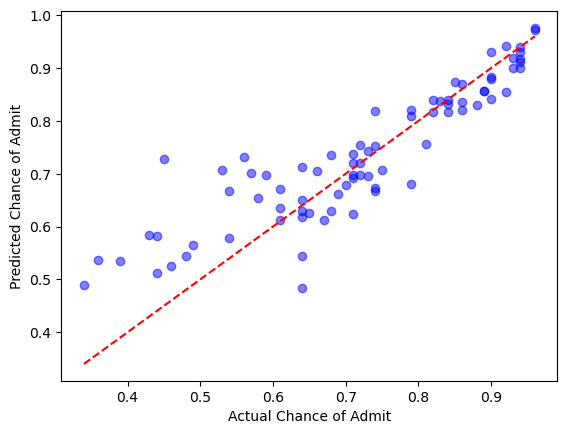

In [50]:
plt.scatter(y_test, pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.show()

# ***Evaluation***

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, pred)
r2

0.780613892079095

In [53]:
mae = mean_absolute_error(y_test, pred)
mae

0.053693346361464875

In [54]:
mse = mean_squared_error(y_test, pred)
mse

0.005665286306724061

In [55]:
rmse = np.sqrt(mse)
rmse

np.float64(0.07526809620765003)

In [56]:
print(f"R2 train: {model.score(x_train, y_train)}")
print(f"R2 test: {model.score(x_test, y_test)}")

R2 train: 0.7550375119817043
R2 test: 0.780613892079095


## ***5. Model Evaluation***

***- MAE shows the average prediction error.***

***- RMSE penalizes larger errors more strongly.***

***- R² score indicates how well the model explains the variance.***

***The model achieved an R² score of 0.780613892079095, meaning it explains 78% of the variation in admission chances.***

## ***6. Conclusion***

***- The model performs reasonably well with an R² score of 78%.***

***- CGPA appears to be the strongest predictor of admission probability.***

***- Academic performance plays a major role in determining admission chances.***